# AutoEncoders: Theory + PyTorch Implementation

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.36MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 266kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


Training Set:

Image batch dimensions: torch.Size([256, 1, 28, 28])
Image label dimensions: torch.Size([256])
tensor([4, 9, 2, 3, 1, 7, 4, 5, 2, 5])
Epoch: 001/030 | Batch 0000/0235 | Loss: 0.2943
Epoch: 002/030 | Batch 0000/0235 | Loss: 0.0619
Epoch: 003/030 | Batch 0000/0235 | Loss: 0.0530
Epoch: 004/030 | Batch 0000/0235 | Loss: 0.0489
Epoch: 005/030 | Batch 0000/0235 | Loss: 0.0473
Epoch: 006/030 | Batch 0000/0235 | Loss: 0.0494
Epoch: 007/030 | Batch 0000/0235 | Loss: 0.0454
Epoch: 008/030 | Batch 0000/0235 | Loss: 0.0468
Epoch: 009/030 | Batch 0000/0235 | Loss: 0.0439
Epoch: 010/030 | Batch 0000/0235 | Loss: 0.0453
Epoch: 011/030 | Batch 0000/0235 | Loss: 0.0424
Epoch: 012/030 | Batch 0000/0235 | Loss: 0.0420
Epoch: 013/030 | Batch 0000/0235 | Loss: 0.0439
Epoch: 014/030 | Batch 0000/0235 | Loss: 0.0405
Epoch: 015/030 | Batch 0000/0235 | Loss: 0.0419
Epoch: 016/030 | Batch 0000/0235 | Loss: 0.0413
Epoch: 017/030 | Batch 0000/0235 | Loss: 0.0418
Epoch: 018/030 | Batch 0000/0235 | 

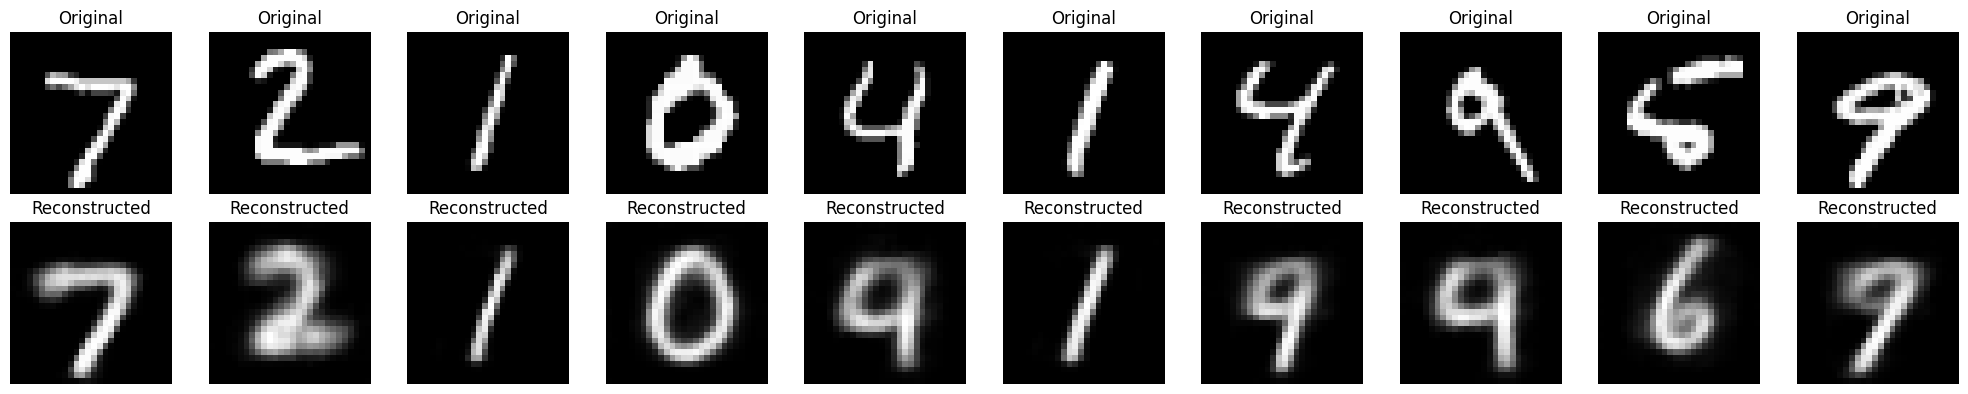

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import sampler
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors


# Hyperparameters
RANDOM_SEED = 999
LEARNING_RATE = 0.0005
BATCH_SIZE = 256
NUM_EPOCHS = 30
NUM_CLASSES = 10


# Define helper class Reshape
class Reshape(nn.Module):
    def __init__(self, *shape):
        super(Reshape, self).__init__()
        self.shape = shape

    def forward(self, x):
        return x.view(self.shape)


# Define helper class Trim
class Trim(nn.Module):
    """Trim the output to ensure proper dimensions."""
    def forward(self, x):
        return x[:, :, :28, :28]


def get_dataloaders_mnist(batch_size, num_workers=0,
                          train_transforms=None, test_transforms=None):

    if train_transforms is None:
        train_transforms = transforms.ToTensor()
    if test_transforms is None:
        test_transforms = transforms.ToTensor()

    # Load datasets
    train_dataset = datasets.MNIST(root='data',
                                   train=True,
                                   transform=train_transforms,
                                   download=True)

    test_dataset = datasets.MNIST(root='data',
                                  train=False,
                                  transform=test_transforms,
                                  download=True)

    # Create DataLoaders
    train_loader = DataLoader(dataset=train_dataset,
                              batch_size=batch_size,
                              num_workers=num_workers,
                              shuffle=True)

    test_loader = DataLoader(dataset=test_dataset,
                             batch_size=batch_size,
                             num_workers=num_workers,
                             shuffle=False)

    return train_loader, test_loader


train_loader, test_loader = get_dataloaders_mnist(batch_size=BATCH_SIZE, num_workers=2)

# Checking the dataset
print('Training Set:\n')
for images, labels in train_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break


class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(      #Compresses the image
            nn.Conv2d(1, 32, stride=(1, 1), kernel_size=(3, 3), padding=1),    #Convolution
            nn.LeakyReLU(0.01),
            nn.Conv2d(32, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
            nn.Flatten(),
            nn.Linear(3136, 2) #Latent representation of 2 numbers
        )
        self.decoder = nn.Sequential(     #Tries to reconstruct the image based on the features from the latent space
            nn.Linear(2, 3136),
            Reshape(-1, 64, 7, 7),
            nn.ConvTranspose2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 32, stride=(2, 2), kernel_size=(3, 3), padding=0),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32, 1, stride=(1, 1), kernel_size=(3, 3), padding=0),  #output_size = (input_size - 1) * stride + kernel_size - 2 * padding, here we get 29x29
            Trim(),  # 1x29x29 -> 1x28x28
            nn.Sigmoid() #Makes sure that every value is between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


model = AutoEncoder()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def compute_epoch_loss_autoencoder(model, data_loader, loss_fn):
    model.eval()
    epoch_loss = 0.0
    with torch.no_grad():
        for features, _ in data_loader:
            logits = model(features)
            loss = loss_fn(logits, features)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)


def train_autoencoder(num_epochs, model, optimizer,
                      train_loader, loss_fn=None,
                      logging_interval=100,
                      skip_epoch_stats=False,
                      save_model=None):
    log_dict = {'train_loss_per_batch': [],
                'train_loss_per_epoch': []}

    if loss_fn is None:
        loss_fn = F.mse_loss

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        for batch_idx, (features, _) in enumerate(train_loader):
            # FORWARD AND BACK PROP
            logits = model(features)
            loss = loss_fn(logits, features)
            optimizer.zero_grad()
            loss.backward()

            # UPDATE MODEL PARAMETERS
            optimizer.step()

            # LOGGING
            log_dict['train_loss_per_batch'].append(loss.item())
            if not batch_idx % logging_interval:
                print('Epoch: %03d/%03d | Batch %04d/%04d | Loss: %.4f' %
                      (epoch+1, num_epochs, batch_idx, len(train_loader), loss))

        if not skip_epoch_stats:
            train_loss = compute_epoch_loss_autoencoder(model, train_loader, loss_fn)
            print('***Epoch: %03d/%03d | Loss: %.3f' %
                  (epoch+1, num_epochs, train_loss))
            log_dict['train_loss_per_epoch'].append(train_loss)

    print('Time elapsed: %.2f min' % ((time.time() - start_time) / 60))
    print('Total Training Time: %.2f min' % ((time.time() - start_time) / 60))

    if save_model is not None:
        torch.save(model.state_dict(), save_model)

    return log_dict


log_dict = train_autoencoder(num_epochs=NUM_EPOCHS,
                             model=model,
                             optimizer=optimizer,
                             train_loader=train_loader,
                             skip_epoch_stats=True,
                             logging_interval=250)


# Function to visualize original and reconstructed images
def visualize_reconstruction(model, data_loader, num_images=10):
    model.eval()
    with torch.no_grad():
        for images, _ in data_loader:
            # Get a batch of images
            reconstructed = model(images)
            break  # Only process the first batch

    # Convert tensors to numpy arrays for visualization
    images = images[:num_images].squeeze().numpy()
    reconstructed = reconstructed[:num_images].squeeze().numpy()

    # Plot the original and reconstructed images
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        # Original images
        axes[0, i].imshow(images[i], cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title("Original")

        # Reconstructed images
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title("Reconstructed")

    plt.tight_layout()
    plt.show()

# Call the function with the trained model and test_loader
visualize_reconstruction(model, test_loader, num_images=10)

**CODE EXPLANATION:**

This code implements and trains an autoencoder using the MNIST dataset, a collection of handwritten digits. An autoencoder is a neural network designed to compress input data into a lower-dimensional latent representation and reconstruct it. The encoder uses convolutional layers to extract features and compress the input image to a two-dimensional representation. The decoder reconstructs the original image using transposed convolutions, reshaping, and activation functions. The training process minimizes reconstruction error, measured by mean squared error (MSE), using the Adam optimizer. The MNIST dataset is loaded using PyTorch's DataLoader, and the autoencoder is trained for 30 epochs, with training and average loss logged for analysis. The structure ensures output dimensions match the MNIST image size (28x28).

**RESULTS:**

Rapid Loss Reduction: In the first few epochs, the model improves significantly (loss drops from ~0.1954 to ~0.05).

Plateauing: By epoch 10 onward, the loss starts to fluctuate slightly, indicating that the model is nearing its optimal performance.

Final Loss:
Epoch 030, Batch 0000: Loss = 0.0396 (indicating the reconstruction error for the final epoch).

A final loss around 0.0396 (MSE) is small and indicates the autoencoder has effectively learned to compress and reconstruct the MNIST digits.







In [ ]:
import matplotlib.pyplot as plt

# get a batch from test set
imgs, _ = next(iter(test_loader))
imgs = imgs.to(device)

# forward pass
with torch.no_grad():
    recons, _ = model(imgs)

imgs = imgs.cpu().numpy()
recons = recons.cpu().numpy()

# visualize first 8
n = 8
plt.figure(figsize=(14,4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(imgs[i].reshape(28,28), cmap='gray')
    ax.set_title("Input")
    plt.axis("off")

    # reconstruction
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(recons[i].reshape(28,28), cmap='gray')
    ax.set_title("Recon")
    plt.axis("off")

plt.suptitle("MNIST Autoencoder — Input vs Reconstruction", y=1.02)
plt.tight_layout()
plt.show()
